In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
df = pd.read_csv('/kaggle/input/datasets/saquib7hussain/k-mean-cluster-dataset/cluster_data.csv')

In [8]:
df.head()

,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature 1  500 non-null    float64
 1   Feature 2  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [13]:


X = df.values

In [14]:

wcss = []
silhouette_avg_scores = []
k_range = range(2, 11) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    
    wcss.append(kmeans.inertia_)
    # This line will now run perfectly:
    silhouette_avg_scores.append(silhouette_score(X, cluster_labels))

# Append an initial inertia calculation for K=1 to match Elbow visual expectations
kmeans_1 = KMeans(n_clusters=1, init='k-means++', n_init=10, random_state=42).fit(X)
wcss_full = [kmeans_1.inertia_] + wcss
k_range_full = range(1, 11)

# STEP 3: TRAIN K-MEANS & PLOT CLUSTERS

In [17]:
# Based on the Kaggle dataset structure, K=3 is the standard blob count
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)

# This line creates the exact variable your environment missed:
y_predictions = final_kmeans.fit_predict(X)

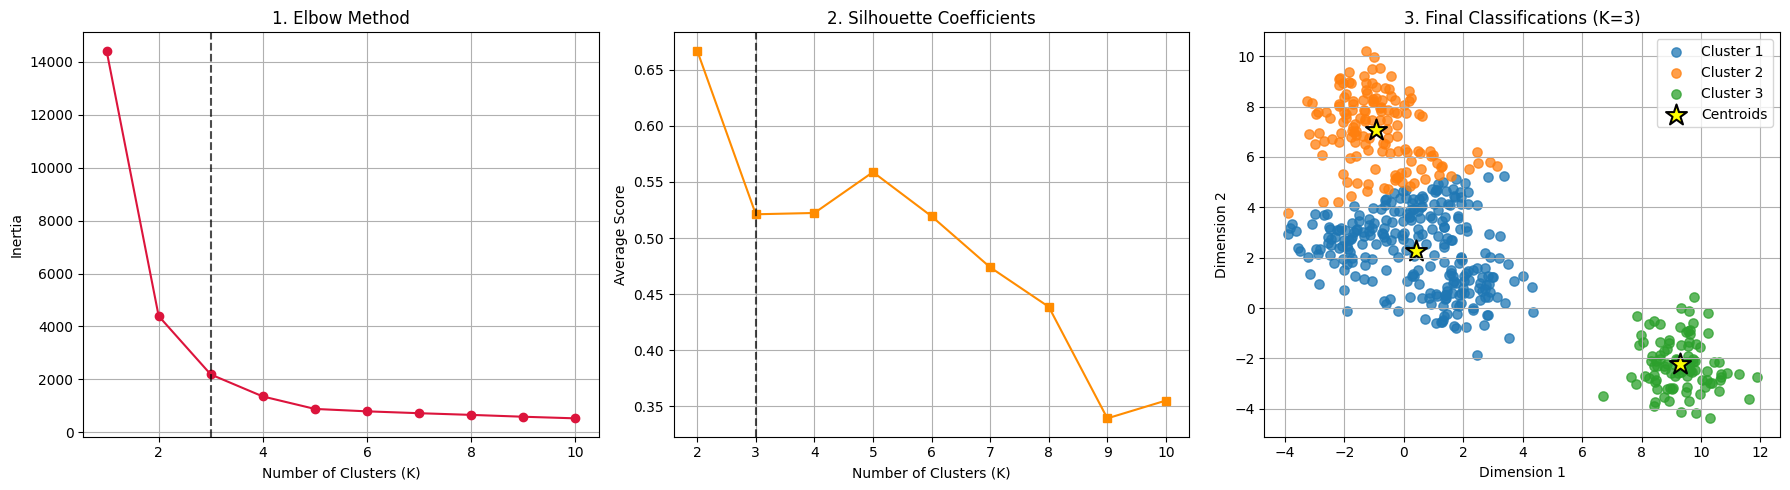

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Elbow
axes[0].plot(k_range_full, wcss_full, marker='o', linestyle='-', color='crimson')
axes[0].axvline(x=optimal_k, linestyle='--', color='black', alpha=0.7)
axes[0].set_title('1. Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

# Plot B: Silhouette
axes[1].plot(k_range, silhouette_avg_scores, marker='s', linestyle='-', color='darkorange')
axes[1].axvline(x=optimal_k, linestyle='--', color='black', alpha=0.7)
axes[1].set_title('2. Silhouette Coefficients')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Average Score')
axes[1].grid(True)

# Plot C: Clusters Map
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i in range(optimal_k):
    axes[2].scatter(X[y_predictions == i, 0], X[y_predictions == i, 1], 
                    s=45, c=colors[i], alpha=0.75, label=f'Cluster {i+1}')

# Add Centroids
axes[2].scatter(final_kmeans.cluster_centers_[:, 0], final_kmeans.cluster_centers_[:, 1], 
                s=250, c='yellow', marker='*', edgecolor='black', linewidth=1.5, label='Centroids')

axes[2].set_title(f'3. Final Classifications (K={optimal_k})')
axes[2].set_xlabel('Dimension 1')
axes[2].set_ylabel('Dimension 2')
axes[2].legend(loc='best')
axes[2].grid(True)

plt.tight_layout()
plt.show()